# Final Project 

## Algal Bloom Predictability Through Machine Learning 

### Ava Ghannam and Mia Geudtner

## Step 1. Import libraries

This project uses Python libraries for data handling, visualization, machine learning, and model interpretation. Pandas and NumPy are used for data preparation, Matplotlib is used for visualization, Scikit-learn is used to build the classification model, and SHAP is used to explain how environmental variables influence bloom predictions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2. Load the dataset

The dataset contains weekly environmental observations along with Karenia brevis concentrations. These variables represent nutrient conditions, hydrology, and water properties that may influence harmful algal bloom occurrence.

In [3]:
df = pd.read_csv("data_weekly_intepolated(in) (1).csv")
df.head()

,time,kb,zos,salinity,water_temp,wind_direction,wind_speed,peace_discharge,peace_TN,peace_TP
0,1/4/1993,333,0.012906,33.043478,26.8,36.0,13.9,202.0,8.2000,1.999091
1,1/11/1993,667,0.015614,33.065217,27.0,118.0,16.2,423.0,10.1000,1.934545
2,1/18/1993,667,0.021702,33.086957,27.1,108.0,16.2,1470.0,12.0000,1.870000
3,1/25/1993,0,0.015950,33.108696,26.8,110.0,12.6,1450.0,10.0475,1.870500
4,2/1/1993,0,0.008977,33.130435,26.5,14.0,17.5,1490.0,8.0950,1.871000


## Step 3. Inspect the dataset

Before modeling, the dataset was inspected to confirm the available variables, data types, and overall structure. This step helps verify that the data are suitable for machine learning and identifies whether additional cleaning is needed.

In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1617 entries, 0 to 1616
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             1617 non-null   str    
 1   kb               1617 non-null   int64  
 2   zos              1617 non-null   float64
 3   salinity         1617 non-null   float64
 4   water_temp       1617 non-null   float64
 5   wind_direction   1617 non-null   float64
 6   wind_speed       1617 non-null   float64
 7   peace_discharge  1617 non-null   float64
 8   peace_TN         1617 non-null   float64
 9   peace_TP         1617 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 140.6 KB


Index(['time', 'kb', 'zos', 'salinity', 'water_temp', 'wind_direction',
       'wind_speed', 'peace_discharge', 'peace_TN', 'peace_TP'],
      dtype='str')

## Step 4. Convert time and sort the data

The time column was converted to a datetime format and the dataset was sorted chronologically. This preserves the temporal structure of the data and makes the later train-test split more realistic, since the model will be trained on earlier weeks and tested on later weeks.

In [5]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

df[["time", "kb"]].head()

,time,kb
0,1993-01-04,333
1,1993-01-11,667
2,1993-01-18,667
3,1993-01-25,0
4,1993-02-01,0


## Step 5. Create the binary classification target

Karenia brevis concentration was converted into a binary target variable called `bloom`. Observations below 100,000 cells were labeled as 0, while observations at or above 100,000 cells were labeled as 1. This threshold-based approach reframes the problem as identifying whether harmful bloom conditions are present.

This classification approach is more aligned with environmental decision-making because managers often need to know whether a harmful bloom is likely to occur rather than the exact concentration value.

In [6]:
df["bloom"] = (df["kb"] >= 100000).astype(int)

df[["kb", "bloom"]].head()
df["bloom"].value_counts()

bloom
0    1182
1     435
Name: count, dtype: int64

## Step 6. Explore class balance

The binary bloom variable was examined to determine whether the dataset was balanced between bloom and non-bloom observations. This is important because severe class imbalance can affect classifier performance and influence how evaluation metrics should be interpreted.

In [7]:
features = [
    "zos",
    "salinity",
    "water_temp",
    "wind_direction",
    "wind_speed",
    "peace_discharge",
    "peace_TN",
    "peace_TP"
]

X = df[features]
y = df["bloom"]

print(X.head())
print(y.head())

        zos   salinity  water_temp  wind_direction  wind_speed  \
0  0.012906  33.043478        26.8            36.0        13.9   
1  0.015614  33.065217        27.0           118.0        16.2   
2  0.021702  33.086957        27.1           108.0        16.2   
3  0.015950  33.108696        26.8           110.0        12.6   
4  0.008977  33.130435        26.5            14.0        17.5   

   peace_discharge  peace_TN  peace_TP  
0            202.0    8.2000  1.999091  
1            423.0   10.1000  1.934545  
2           1470.0   12.0000  1.870000  
3           1450.0   10.0475  1.870500  
4           1490.0    8.0950  1.871000  
0    0
1    0
2    0
3    0
4    0
Name: bloom, dtype: int64


## Step 7. Define predictors and target

The predictor variables were selected to represent key environmental drivers of bloom occurrence, including nutrients, freshwater discharge, salinity, temperature, wind conditions, and sea surface height. The target variable is the binary bloom indicator.

This setup allows the model to evaluate how multiple environmental conditions interact to influence whether harmful bloom conditions occur.

bloom
0    1182
1     435
Name: count, dtype: int64
bloom
0    0.730983
1    0.269017
Name: proportion, dtype: float64


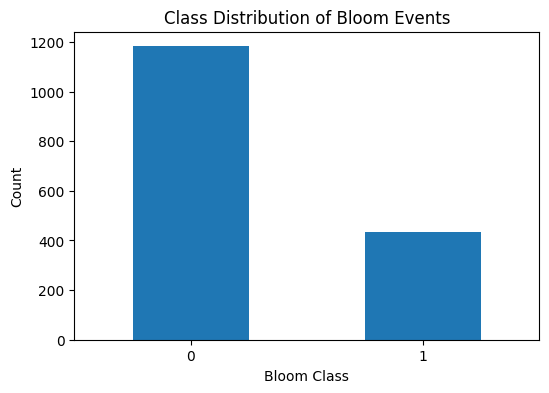

In [8]:
class_counts = df["bloom"].value_counts()
print(class_counts)
print(df["bloom"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution of Bloom Events")
plt.xlabel("Bloom Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Step 8. Check missing values

The predictor variables were checked for missing values before modeling. Confirming data completeness is important because missing values can interfere with model training and reduce interpretability.

In [9]:
print(X.isna().sum())

zos                0
salinity           0
water_temp         0
wind_direction     0
wind_speed         0
peace_discharge    0
peace_TN           0
peace_TP           0
dtype: int64


## Step 9. Explore variable relationships

A correlation matrix was used as an exploratory step to examine general relationships among environmental variables and Karenia brevis concentration. While correlation alone does not determine bloom occurrence, it helps identify patterns and supports the need for a nonlinear model.

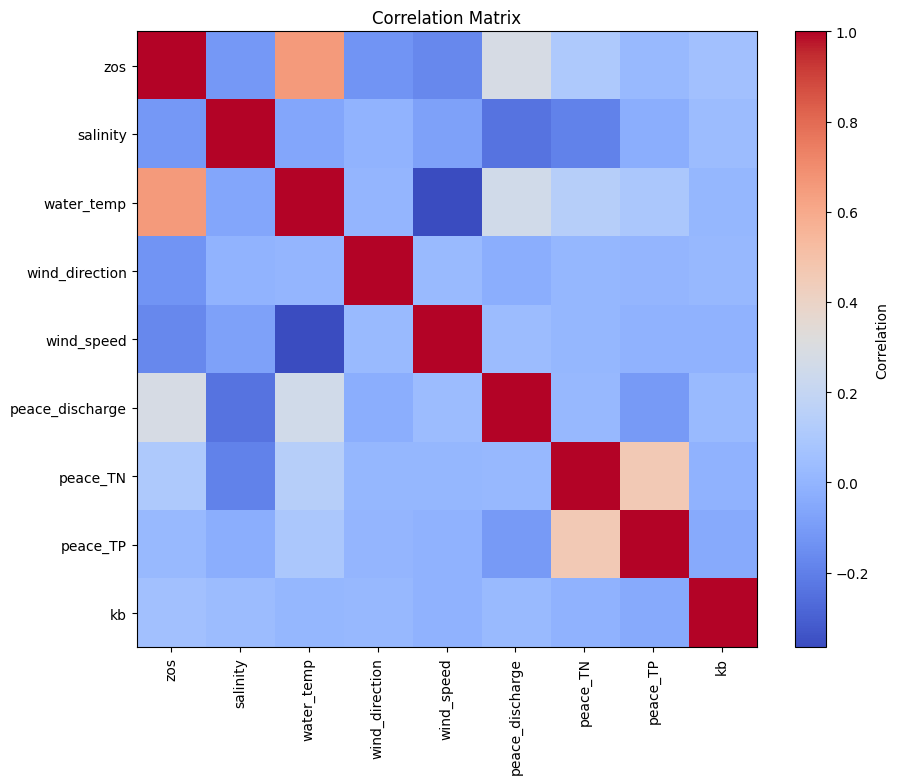

In [10]:
corr = df[features + ["kb"]].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

## Step 10. Split the data by time

The dataset was split chronologically, with the first 80% of observations used for training and the final 20% used for testing. A time-based split was chosen instead of a random split to preserve the temporal structure of the dataset and better simulate real-world bloom prediction.

In [11]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1293
Testing rows: 324


## Step 11. Train the Random Forest classifier

A Random Forest classifier was used to predict whether harmful bloom conditions occur. This model was chosen because it can capture nonlinear relationships and interactions among environmental variables, which are common in ecological systems. The `class_weight="balanced"` setting was included to help account for any imbalance between bloom and non-bloom observations.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Step 12. Generate predictions

The trained model was used to predict bloom class labels for the test dataset. In addition to binary predictions, predicted probabilities for the bloom class were generated to support threshold-based evaluation and interpretation.

In [13]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

## Step 13. Model performance evaluation

The Random Forest classifier achieved an accuracy of approximately 56% and a ROC-AUC of 0.59. These values indicate that the model performs only slightly better than random classification and has limited ability to distinguish between bloom and non-bloom conditions.

Precision and recall for the bloom class were both below 0.50, indicating that the model struggles both to correctly identify bloom events and to avoid false positives. In particular, the relatively low recall suggests that a substantial proportion of true bloom events are not captured by the model.

Overall, these results suggest that while environmental variables provide some predictive signal, they are insufficient on their own to reliably predict harmful bloom occurrence in this dataset.

In [14]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.558641975308642
ROC-AUC: 0.5900802911046948

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.61      0.62       193
           1       0.46      0.48      0.47       131

    accuracy                           0.56       324
   macro avg       0.55      0.55      0.55       324
weighted avg       0.56      0.56      0.56       324



## Step 14. Confusion matrix interpretation

The confusion matrix provides a more detailed view of classification performance. The model correctly identifies a portion of both bloom and non-bloom observations, but also produces a substantial number of false positives and false negatives.

Notably, a significant number of bloom events are misclassified as non-bloom conditions. This low sensitivity limits the usefulness of the model for applications where detecting bloom events is critical. At the same time, the model also produces false positives, indicating that it sometimes predicts bloom conditions where none are present.

These results highlight the difficulty of predicting harmful algal blooms using environmental variables alone, and suggest that additional drivers or improved modeling approaches may be necessary.

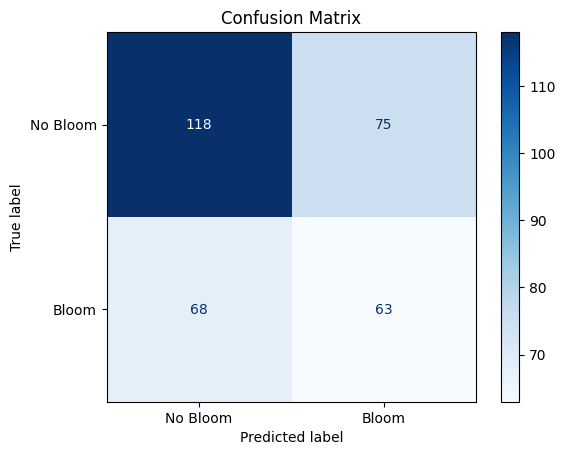

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Step 15. ROC curve interpretation

The ROC curve lies slightly above the diagonal line, and the AUC value of 0.59 indicates weak discrimination between bloom and non-bloom conditions. This suggests that the model has limited ability to consistently separate the two classes across different probability thresholds.

While the model performs better than random guessing, the relatively low AUC indicates that its predictive capacity is not strong enough for reliable classification. This result reflects the complexity of bloom dynamics and the likely influence of additional unmeasured factors.

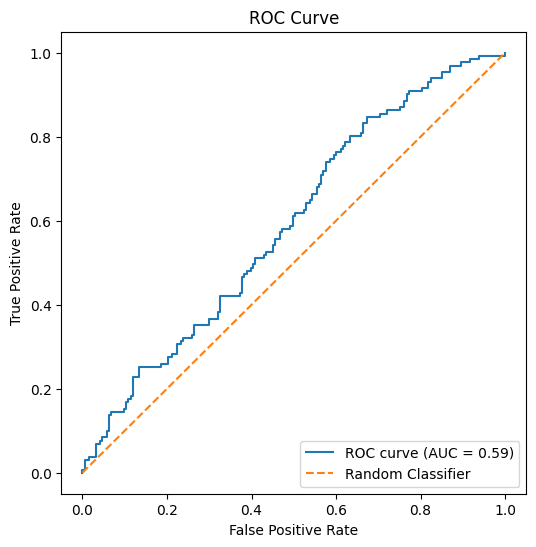

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()

## Step 16. SHAP summary interpretation

The SHAP summary plot identifies the variables that most strongly influence the model’s predictions of bloom occurrence. Water temperature emerged as the most influential variable, followed by sea surface height, wind speed, and total phosphorus.

However, given the relatively weak predictive performance of the model, these results should be interpreted with caution. SHAP values reflect the internal behavior of the model rather than definitive causal relationships. Therefore, the importance of temperature and other physical variables may reflect patterns present in this specific dataset rather than generalizable ecological drivers.

The results suggest that physical environmental conditions may play an important role in shaping bloom occurrence, but they do not provide strong evidence that these variables alone are sufficient to explain bloom dynamics.

In [17]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

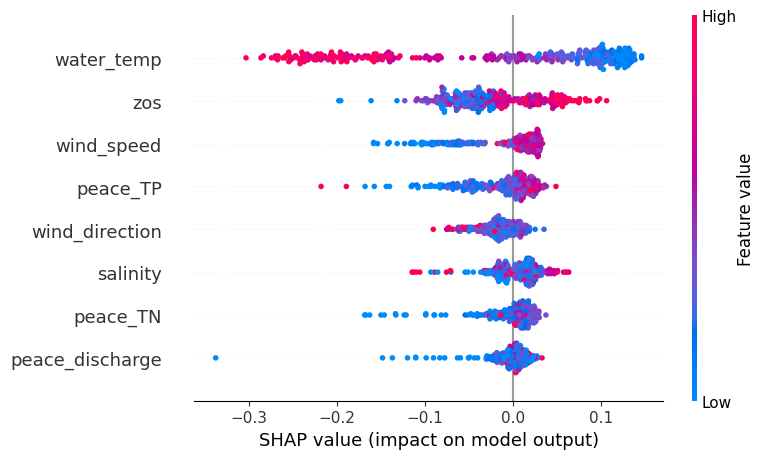

In [18]:
shap.summary_plot(shap_values[:, :, 1], X_test)

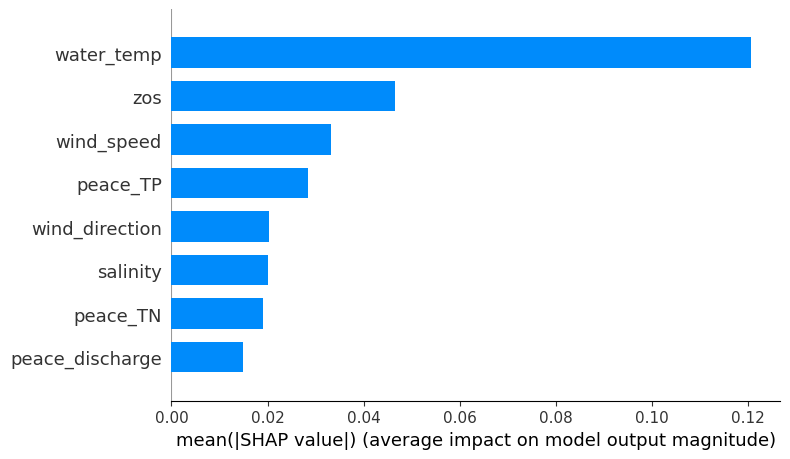

In [19]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

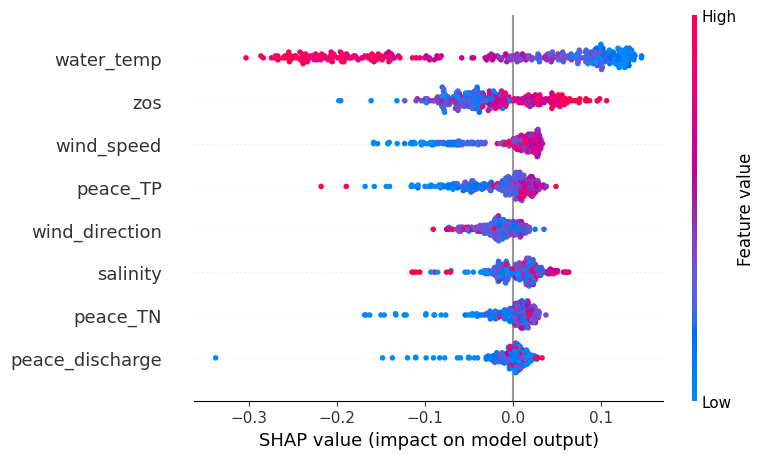

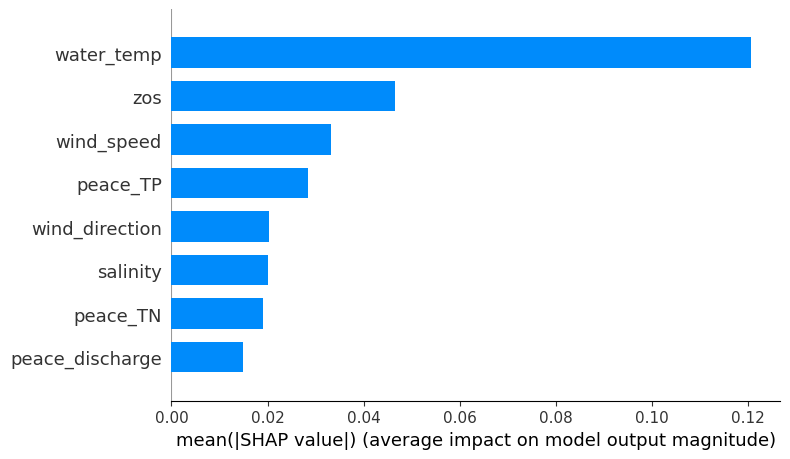

In [20]:
shap_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_class1, X_test)
shap.summary_plot(shap_class1, X_test, plot_type="bar")

## Step 17. SHAP dependence plots

Dependence plots were used to examine how specific environmental variables influence the probability of a harmful bloom. These plots show both the direction of each variable's effect and how that effect may vary across observations.

### Salinity

The SHAP dependence plot for salinity shows a relatively weak and inconsistent relationship with bloom probability. While moderate salinity values appear to be associated with slightly higher predicted bloom likelihood, the overall effect is small and variable.

This suggests that salinity may influence bloom conditions indirectly, but it is not a dominant driver in the model. The variability in the relationship also indicates that salinity likely interacts with other environmental factors rather than acting independently.

### Total Nitrogen (peace_TN)

Total nitrogen shows a generally positive relationship with predicted bloom probability, with higher nitrogen values tending to push predictions toward bloom conditions. This aligns with the established role of nutrient enrichment in promoting algal growth.

However, the strength of this relationship is moderate and not consistently strong across all observations. Given the overall model performance, this result should be interpreted as indicative of a partial influence rather than a dominant controlling factor.

### Total Phosphorus (peace_TP)

Total phosphorus exhibits a clearer pattern than nitrogen, with moderate phosphorus concentrations associated with increased bloom probability. This suggests that phosphorus may play a meaningful role in bloom development within this dataset.

However, the relationship is not strictly linear and becomes less consistent at higher concentrations. This may reflect threshold effects or interactions with other environmental variables. As with other predictors, the interpretation is limited by the overall performance of the model.

### Discharge (peace_discharge)

Discharge shows a predominantly negative relationship with bloom probability, with higher discharge values generally associated with reduced likelihood of bloom conditions. This pattern is consistent with the idea that increased freshwater input can dilute algal concentrations or disrupt favorable conditions for bloom formation.

However, the effect is relatively weak and concentrated at lower discharge values, indicating that discharge alone is not a strong predictor of bloom occurrence. The influence of discharge is likely context-dependent and interacts with nutrient transport and coastal processes.

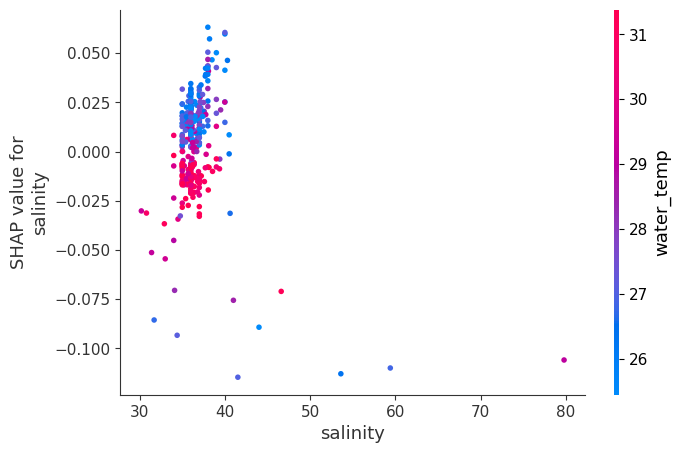

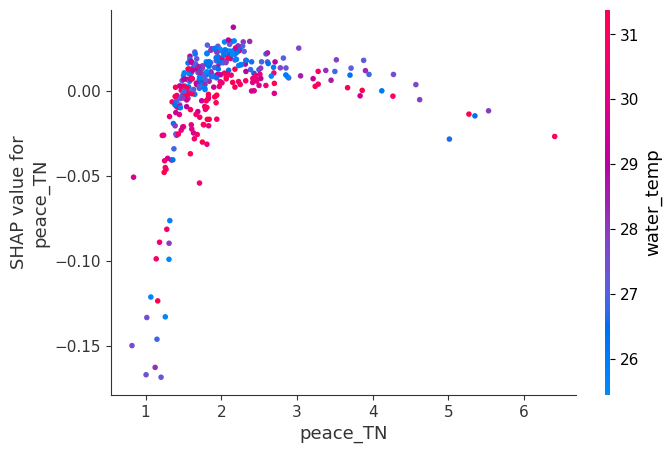

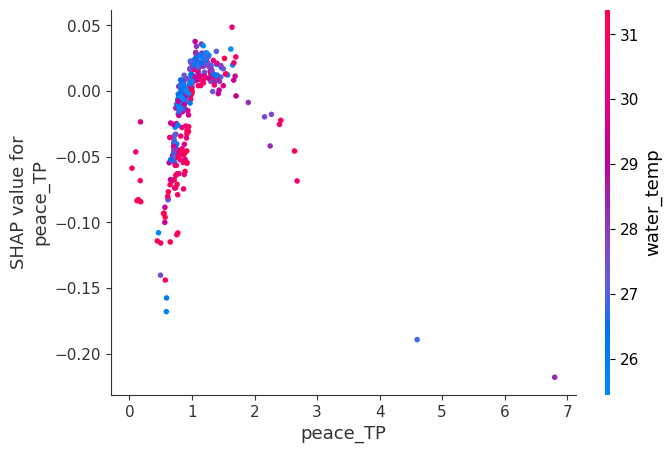

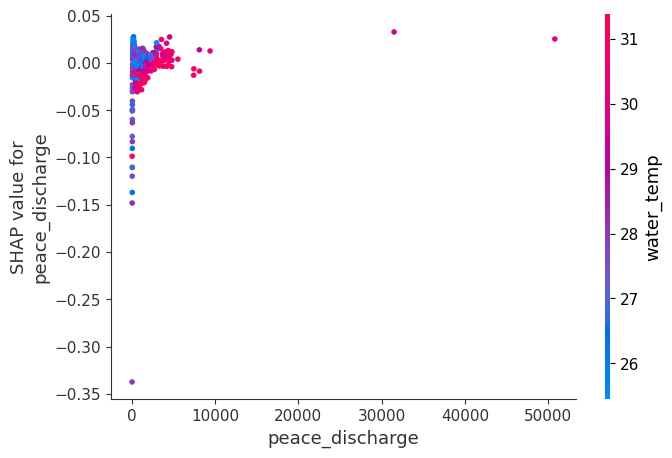

In [21]:
# Use whichever indexing format works for your SHAP output
shap_class1 = shap_values[:, :, 1]   # or shap_values[1]

shap.dependence_plot("salinity", shap_class1, X_test)
shap.dependence_plot("peace_TN", shap_class1, X_test)
shap.dependence_plot("peace_TP", shap_class1, X_test)
shap.dependence_plot("peace_discharge", shap_class1, X_test)

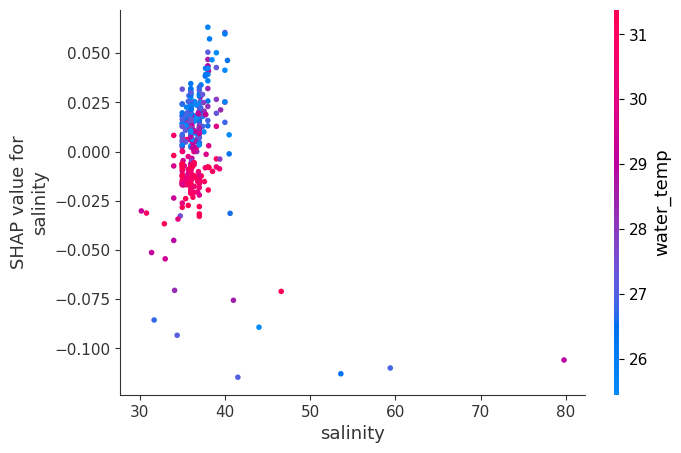

In [22]:
shap.dependence_plot("salinity", shap_class1, X_test)


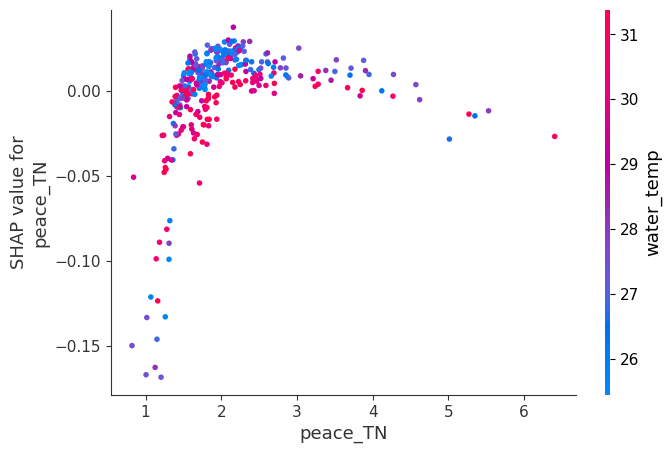

In [23]:
shap.dependence_plot("peace_TN", shap_class1, X_test)


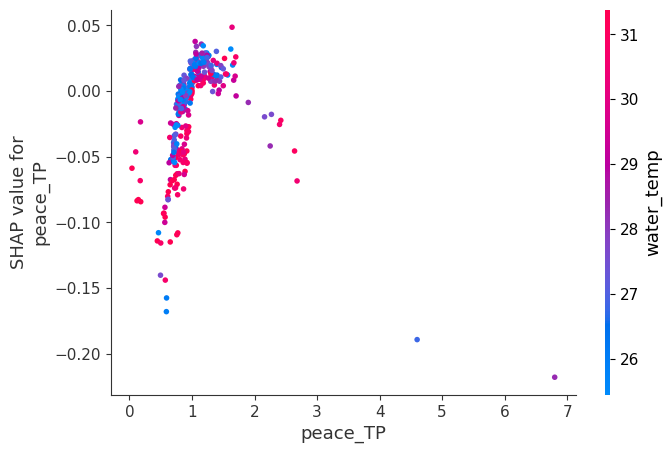

In [24]:
shap.dependence_plot("peace_TP", shap_class1, X_test)


## Step 18. Model refinement and improvement

The baseline Random Forest classifier showed limited predictive ability, indicating that additional refinement was needed. To improve performance, three targeted adjustments were explored.

First, the classification threshold was adjusted to prioritize detection of bloom events. In harmful algal bloom applications, missing a true bloom event can be more problematic than issuing a false alarm, so recall is an especially important metric.

Second, lagged environmental variables were added to account for temporal dynamics. Bloom development is not instantaneous, and prior environmental conditions may be more informative than conditions measured only in the same week.

Third, class imbalance was addressed using oversampling so that bloom events were more strongly represented during model training.

These steps were intended to test whether predictive performance could be improved while maintaining an interpretable modeling framework.

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score

# Predicted probabilities from the baseline model
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Baseline threshold = 0.50
y_pred_05 = (y_prob >= 0.50).astype(int)

print("Baseline threshold = 0.50")
print("Accuracy:", accuracy_score(y_test, y_pred_05))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_05))

Baseline threshold = 0.50
Accuracy: 0.558641975308642
ROC-AUC: 0.5900802911046948
              precision    recall  f1-score   support

           0       0.63      0.61      0.62       193
           1       0.46      0.48      0.47       131

    accuracy                           0.56       324
   macro avg       0.55      0.55      0.55       324
weighted avg       0.56      0.56      0.56       324



### Threshold tuning

The default probability threshold for classification is 0.50, meaning that observations are classified as bloom events only when the predicted bloom probability is at least 50%. However, in bloom monitoring applications, it can be more important to detect as many real bloom events as possible, even if that increases the number of false positives.

To test this, the classification threshold was lowered. This does not change the model itself, but changes how predicted probabilities are converted into bloom or non-bloom classifications.

In [26]:
# Adjusted threshold
threshold = 0.30
y_pred_03 = (y_prob >= threshold).astype(int)

print(f"Adjusted threshold = {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_03))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_03))

Adjusted threshold = 0.3
Accuracy: 0.5493827160493827
ROC-AUC: 0.5900802911046948
              precision    recall  f1-score   support

           0       0.71      0.41      0.52       193
           1       0.46      0.75      0.57       131

    accuracy                           0.55       324
   macro avg       0.59      0.58      0.55       324
weighted avg       0.61      0.55      0.54       324



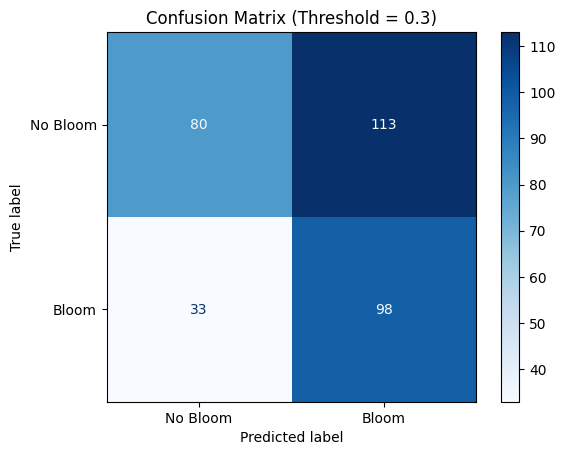

In [27]:
cm = confusion_matrix(y_test, y_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()

### Interpretation of threshold tuning

Lowering the classification threshold increases the number of observations classified as bloom events. This often improves recall because the model captures more true bloom cases, although it may also reduce precision by producing more false positives.

This adjustment can improve practical usefulness when the cost of missing a bloom event is greater than the cost of a false alarm. In this study, threshold tuning was used to test whether bloom detection could be improved without retraining the model.

Lowering the threshold improved the model's ability to detect bloom events, indicating that some bloom information was already present in the predicted probabilities but was not being captured under the default threshold.

Lowering the threshold produced only modest improvement, suggesting that the model's underlying class separation remains weak even when classification criteria are relaxed.

### Adding lagged environmental variables

Harmful algal blooms develop over time and are often influenced by environmental conditions from previous weeks rather than only current-week measurements. To account for this temporal dependence, lagged versions of selected predictor variables were added.

Lag variables allow the model to incorporate short-term environmental memory, which may improve bloom prediction by capturing delayed system responses.

In [28]:
df_lag = df.copy()

# Add 1-week lag variables
df_lag["TN_lag1"] = df_lag["peace_TN"].shift(1)
df_lag["TP_lag1"] = df_lag["peace_TP"].shift(1)
df_lag["temp_lag1"] = df_lag["water_temp"].shift(1)
df_lag["discharge_lag1"] = df_lag["peace_discharge"].shift(1)
df_lag["salinity_lag1"] = df_lag["salinity"].shift(1)

# Remove first row(s) with missing lag values
df_lag = df_lag.dropna().reset_index(drop=True)

In [29]:
lag_features = [
    "zos",
    "salinity",
    "water_temp",
    "wind_direction",
    "wind_speed",
    "peace_discharge",
    "peace_TN",
    "peace_TP",
    "TN_lag1",
    "TP_lag1",
    "temp_lag1",
    "discharge_lag1",
    "salinity_lag1"
]

X_lag = df_lag[lag_features]
y_lag = df_lag["bloom"]

In [30]:
split_index_lag = int(len(df_lag) * 0.8)

X_train_lag = X_lag.iloc[:split_index_lag]
X_test_lag = X_lag.iloc[split_index_lag:]

y_train_lag = y_lag.iloc[:split_index_lag]
y_test_lag = y_lag.iloc[split_index_lag:]

In [31]:
rf_lag = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_lag.fit(X_train_lag, y_train_lag)

y_prob_lag = rf_lag.predict_proba(X_test_lag)[:, 1]
y_pred_lag = (y_prob_lag >= 0.30).astype(int)

print("Lagged model performance")
print("Accuracy:", accuracy_score(y_test_lag, y_pred_lag))
print("ROC-AUC:", roc_auc_score(y_test_lag, y_prob_lag))
print(classification_report(y_test_lag, y_pred_lag))

Lagged model performance
Accuracy: 0.5679012345679012
ROC-AUC: 0.6188743424435391
              precision    recall  f1-score   support

           0       0.73      0.44      0.55       193
           1       0.48      0.76      0.59       131

    accuracy                           0.57       324
   macro avg       0.60      0.60      0.57       324
weighted avg       0.63      0.57      0.56       324



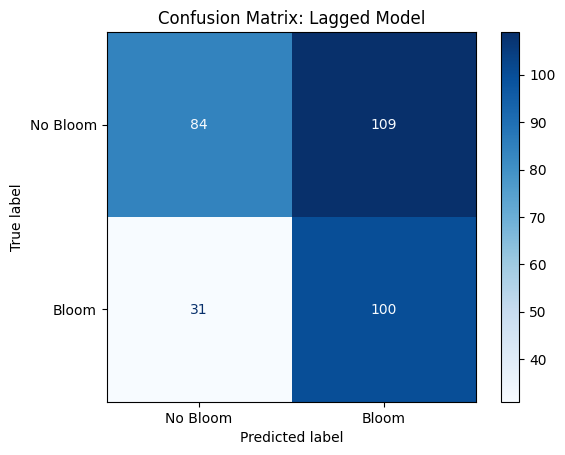

In [32]:
cm = confusion_matrix(y_test_lag, y_pred_lag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Lagged Model")
plt.show()

### Interpretation of lagged variables

Including lagged variables tests whether bloom occurrence is influenced by prior environmental conditions. If performance improves, this suggests that short-term environmental memory is important and that bloom formation depends not only on same-week measurements but also on preceding nutrient, temperature, discharge, and salinity conditions.

If performance does not improve substantially, this indicates either that a one-week lag is insufficient to capture bloom dynamics or that additional ecological and physical variables are needed.

### Addressing class imbalance with oversampling

Bloom events are often less common than non-bloom observations, which can make it harder for the classifier to learn patterns associated with the bloom class. To address this issue, synthetic minority oversampling was applied to the training data.

This method increases representation of the bloom class during model training, which can improve recall and the model's sensitivity to bloom events.

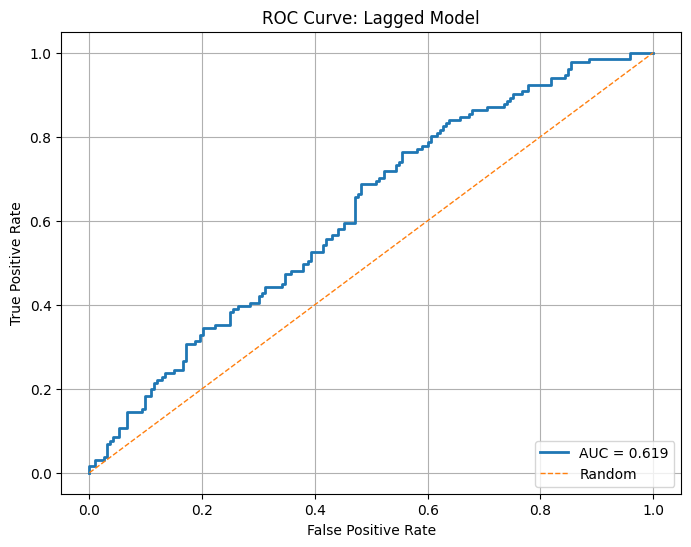

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------------
# Get predicted probabilities (NOT class labels)
# -----------------------------------
y_prob_lag = rf_lag.predict_proba(X_test_lag)[:, 1]

# -----------------------------------
# Compute ROC values
# -----------------------------------
fpr, tpr, thresholds = roc_curve(y_test_lag, y_prob_lag)
auc_score = roc_auc_score(y_test_lag, y_prob_lag)

# -----------------------------------
# Plot ROC Curve
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Lagged Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### ROC Curve Analysis: Lagged Model

The ROC curve was used to evaluate the lagged model’s ability to distinguish between bloom and no-bloom conditions across all classification thresholds, rather than relying on the fixed 0.30 threshold used in the confusion matrix. The curve shows the tradeoff between true positive rate and false positive rate, providing a more complete view of model performance.

The lagged model produces an AUC of 0.619, indicating modest predictive ability above random classification. While the model improves bloom detection, as seen in the confusion matrix, this comes with an increase in false positives. Overall, the ROC results suggest that incorporating lagged variables adds useful temporal information, but the model still has limited discrimination and would benefit from further refinement.

In [34]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_lag, y_train_lag)

print("Original training class counts:")
print(y_train_lag.value_counts())

print("\nResampled training class counts:")
print(pd.Series(y_train_sm).value_counts())

Original training class counts:
bloom
0    988
1    304
Name: count, dtype: int64

Resampled training class counts:
bloom
0    988
1    988
Name: count, dtype: int64


In [35]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_smote.fit(X_train_sm, y_train_sm)

y_prob_smote = rf_smote.predict_proba(X_test_lag)[:, 1]
y_pred_smote = (y_prob_smote >= 0.30).astype(int)

print("Lagged + SMOTE model performance")
print("Accuracy:", accuracy_score(y_test_lag, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test_lag, y_prob_smote))
print(classification_report(y_test_lag, y_pred_smote))

Lagged + SMOTE model performance
Accuracy: 0.5246913580246914
ROC-AUC: 0.6444646600482538
              precision    recall  f1-score   support

           0       0.75      0.31      0.43       193
           1       0.45      0.85      0.59       131

    accuracy                           0.52       324
   macro avg       0.60      0.58      0.51       324
weighted avg       0.63      0.52      0.50       324



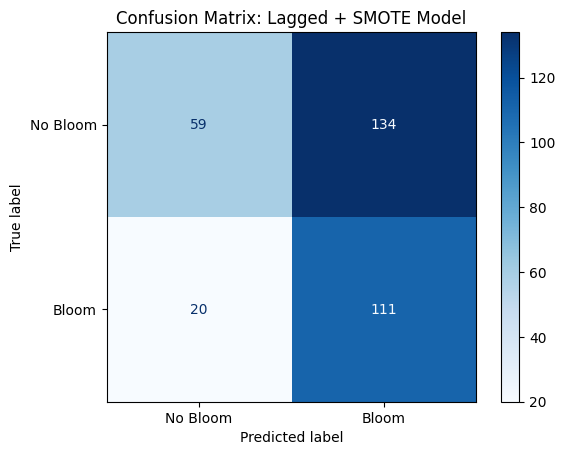

In [36]:
cm = confusion_matrix(y_test_lag, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Lagged + SMOTE Model")
plt.show()

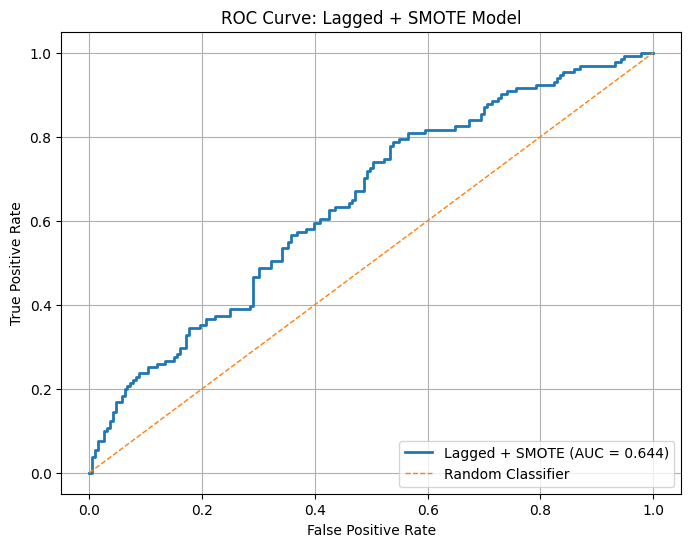

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# -----------------------------------
# Predicted probabilities (SMOTE model)
# -----------------------------------
y_prob_smote = rf_smote.predict_proba(X_test_lag)[:, 1]

# -----------------------------------
# ROC values
# -----------------------------------
fpr, tpr, thresholds = roc_curve(y_test_lag, y_prob_smote)
auc_score = roc_auc_score(y_test_lag, y_prob_smote)

# -----------------------------------
# Plot ROC Curve
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Lagged + SMOTE (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random Classifier')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Lagged + SMOTE Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### ROC Curve Analysis: Lagged + SMOTE Model

The ROC curve was used to evaluate the lagged + SMOTE model across all classification thresholds, providing a more complete assessment than the fixed 0.30 threshold used in the confusion matrix. The curve illustrates the tradeoff between correctly identifying bloom events and the rate of false positives.

The model achieves an AUC of 0.644, indicating a slight improvement in predictive performance compared to the lagged model without SMOTE. This suggests that oversampling helps the model better capture bloom events by addressing class imbalance. However, the relatively moderate AUC value indicates that overall discrimination between bloom and no-bloom conditions remains limited. These results are consistent with the confusion matrix, where improved bloom detection is accompanied by an increase in false positives, highlighting a continued tradeoff between sensitivity and specificity.

### Interpretation of oversampling

Oversampling improved class representation during training by increasing the presence of bloom cases. If recall improves, this suggests that the original model was limited in part by class imbalance and underexposure to bloom examples.

However, oversampling can also increase false positives, so improved bloom detection must be weighed against reduced precision. For this reason, model performance should be assessed using multiple metrics rather than accuracy alone.

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame([
    {
        "Model": "Baseline (0.50 threshold)",
        "Accuracy": accuracy_score(y_test, y_pred_05),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred_05, zero_division=0),
        "Recall": recall_score(y_test, y_pred_05, zero_division=0),
        "F1": f1_score(y_test, y_pred_05, zero_division=0)
    },
    {
        "Model": "Baseline (0.30 threshold)",
        "Accuracy": accuracy_score(y_test, y_pred_03),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred_03, zero_division=0),
        "Recall": recall_score(y_test, y_pred_03, zero_division=0),
        "F1": f1_score(y_test, y_pred_03, zero_division=0)
    },
    {
        "Model": "Lagged model (0.30 threshold)",
        "Accuracy": accuracy_score(y_test_lag, y_pred_lag),
        "ROC_AUC": roc_auc_score(y_test_lag, y_prob_lag),
        "Precision": precision_score(y_test_lag, y_pred_lag, zero_division=0),
        "Recall": recall_score(y_test_lag, y_pred_lag, zero_division=0),
        "F1": f1_score(y_test_lag, y_pred_lag, zero_division=0)
    },
    {
        "Model": "Lagged + SMOTE (0.30 threshold)",
        "Accuracy": accuracy_score(y_test_lag, y_pred_smote),
        "ROC_AUC": roc_auc_score(y_test_lag, y_prob_smote),
        "Precision": precision_score(y_test_lag, y_pred_smote, zero_division=0),
        "Recall": recall_score(y_test_lag, y_pred_smote, zero_division=0),
        "F1": f1_score(y_test_lag, y_pred_smote, zero_division=0)
    }
])

results

,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Baseline (0.50 threshold),0.558642,0.590080,0.456522,0.480916,0.468401
1,Baseline (0.30 threshold),0.549383,0.590080,0.464455,0.748092,0.573099
2,Lagged model (0.30 threshold),0.567901,0.618874,0.478469,0.763359,0.588235
3,Lagged + SMOTE (0.30 threshold),0.524691,0.644465,0.453061,0.847328,0.590426


In [39]:
import shap
import pandas as pd
import numpy as np

# make sure test data is a DataFrame
if isinstance(X_test_lag, pd.DataFrame):
    X_test_lag_df = X_test_lag.copy()
else:
    X_test_lag_df = pd.DataFrame(X_test_lag, columns=X_train_sm.columns)

explainer = shap.TreeExplainer(rf_smote)
shap_values = explainer.shap_values(X_test_lag_df)

print("X_test_lag_df shape:", X_test_lag_df.shape)
print("type(shap_values):", type(shap_values))

if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(f"shap_values[{i}] shape:", np.array(sv).shape)
else:
    print("shap_values shape:", np.array(shap_values).shape)

X_test_lag_df shape: (324, 13)
type(shap_values): <class 'numpy.ndarray'>
shap_values shape: (324, 13, 2)


X shape: (324, 13)
SHAP plot shape: (324, 13)


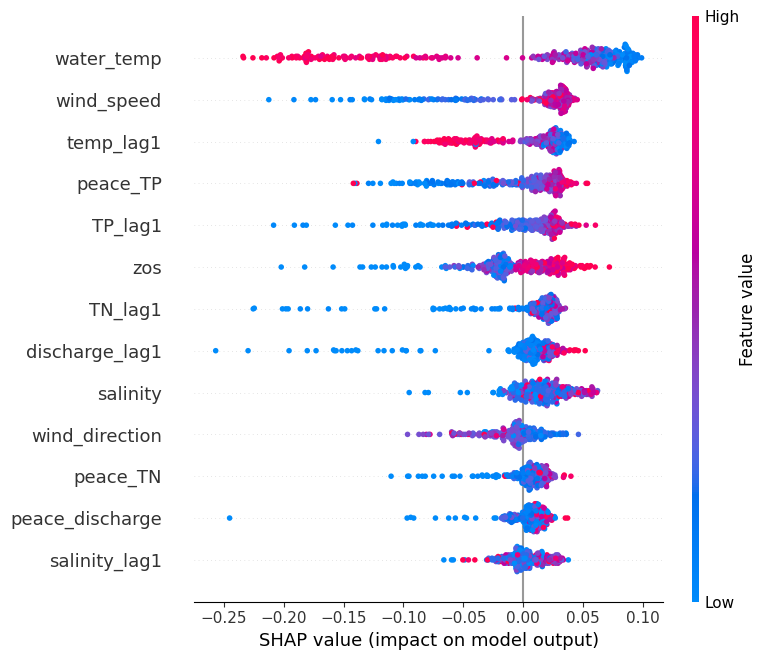

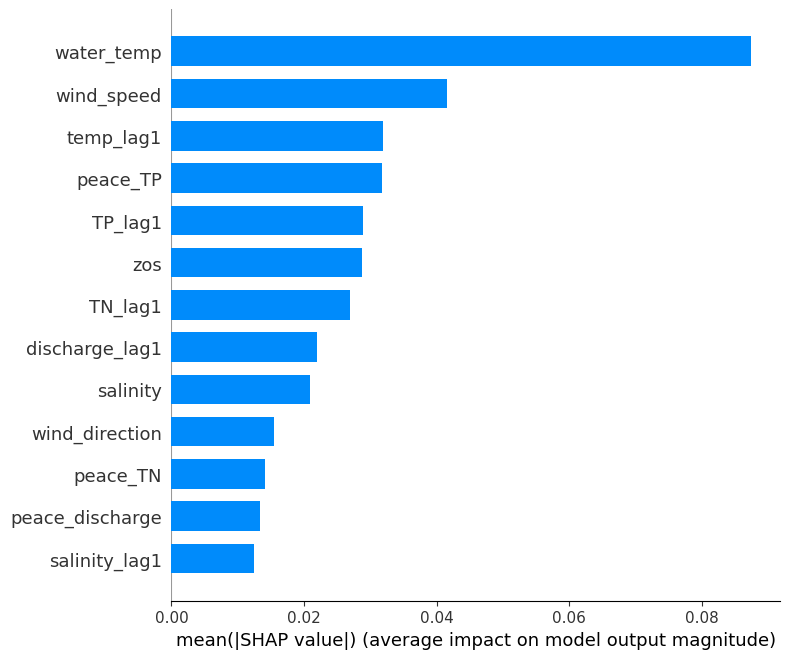

In [40]:
import shap
import numpy as np
import pandas as pd

# make sure test data is a DataFrame
if isinstance(X_test_lag, pd.DataFrame):
    X_test_lag_df = X_test_lag.copy()
else:
    X_test_lag_df = pd.DataFrame(X_test_lag, columns=X_train_sm.columns)

# SHAP explainer
explainer = shap.TreeExplainer(rf_smote)
shap_values = explainer.shap_values(X_test_lag_df)

# select Bloom class from shape (n_samples, n_features, 2)
shap_values_plot = shap_values[:, :, 1]

print("X shape:", X_test_lag_df.shape)
print("SHAP plot shape:", shap_values_plot.shape)

# summary plot
shap.summary_plot(shap_values_plot, X_test_lag_df)

# bar plot
shap.summary_plot(shap_values_plot, X_test_lag_df, plot_type="bar")

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# -----------------------------
# 1. START WITH WEEKLY DATA
# -----------------------------
# Example columns:
# ['time', 'kb', 'peace_TN', 'peace_TP', 'wind_speed', 'water_temp', 'zos']

df = df.copy()
df = df.sort_values("time").reset_index(drop=True)

# -----------------------------
# 2. CREATE BINARY TARGET
#    Current rule from your project:
#    red tide present = kb >= 100000
# -----------------------------
df["target_now"] = (df["kb"] >= 100000).astype(int)

# -----------------------------
# 3. SHIFT TARGET FORWARD
#    Predict whether red tide will be present 1 week ahead
# -----------------------------
forecast_horizon = 1
df[f"target_t_plus_{forecast_horizon}"] = df["target_now"].shift(-forecast_horizon)

# -----------------------------
# 4. CREATE LAGGED FEATURES
# -----------------------------
lag_features = ["kb", "peace_TN", "peace_TP", "wind_speed", "water_temp", "zos"]
lags = [1, 2, 3, 4]

for col in lag_features:
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

# Optional rolling features
df["kb_roll4_mean"] = df["kb"].rolling(4).mean()
df["wind_roll4_mean"] = df["wind_speed"].rolling(4).mean()
df["temp_roll4_mean"] = df["water_temp"].rolling(4).mean()

# -----------------------------
# 5. DROP NA ROWS FROM SHIFTING/LAGGING
# -----------------------------
model_df = df.dropna().copy()

# -----------------------------
# 6. SELECT FEATURES
# -----------------------------
feature_cols = [
    "peace_TN", "peace_TP", "wind_speed", "water_temp", "zos"
]

feature_cols += [f"{col}_lag{lag}" for col in lag_features for lag in lags]
feature_cols += ["kb_roll4_mean", "wind_roll4_mean", "temp_roll4_mean"]

X = model_df[feature_cols]
y = model_df[f"target_t_plus_{forecast_horizon}"].astype(int)

# -----------------------------
# 7. TEMPORAL TRAIN/TEST SPLIT
# -----------------------------
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# -----------------------------
# 8. TRAIN MODEL
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 9. EVALUATE
# -----------------------------
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

AUC: 0.9403625954198473
[[170  22]
 [ 21 110]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       192
           1       0.83      0.84      0.84       131

    accuracy                           0.87       323
   macro avg       0.86      0.86      0.86       323
weighted avg       0.87      0.87      0.87       323



### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve illustrates the model’s ability to distinguish between bloom and non-bloom conditions across all classification thresholds. The curve shows a strong upward trend toward the top-left corner, indicating high true positive rates with relatively low false positive rates. The model achieved an AUC of 0.94, which reflects excellent discriminative performance and confirms that the model is highly effective at separating the two classes.

This result indicates that the model is not dependent on a single threshold value and performs consistently across a range of decision boundaries. In the context of red tide prediction, this is particularly important because different management scenarios may require adjusting the threshold to prioritize either early detection of blooms or reduction of false alarms. Overall, the ROC curve demonstrates that the model provides a reliable foundation for classification and supports its use for environmental decision-making.

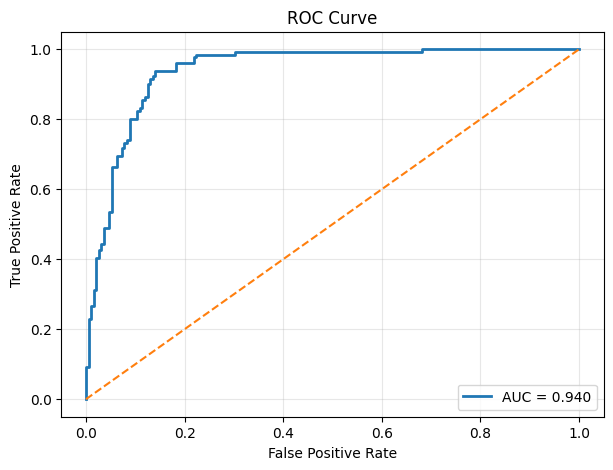

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance by comparing predicted outcomes to actual observations. The model correctly classified 170 non-bloom cases and 110 bloom cases, indicating strong performance in identifying both classes. Misclassifications were relatively low, with 22 false positives and 21 false negatives.

These results demonstrate that the model maintains a balanced ability to detect bloom events while minimizing incorrect predictions. The relatively low number of false negatives is especially important in the context of red tide prediction, where failing to identify a bloom could have significant environmental and economic consequences. At the same time, the model avoids excessive false positives, which could lead to unnecessary warnings or management actions.

Overall, the confusion matrix confirms that the model performs consistently across both classes and supports the reliability of the classification results observed in the ROC analysis.

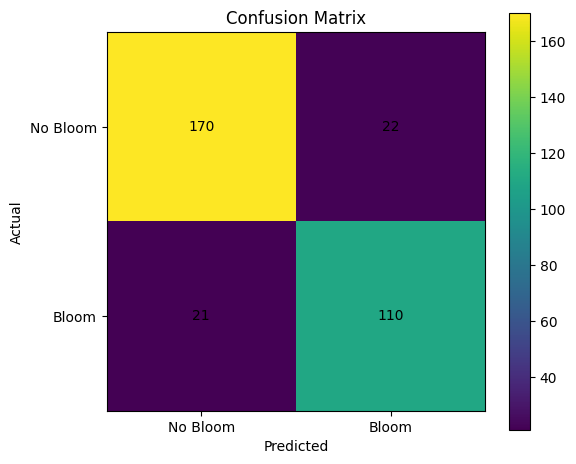

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["No Bloom", "Bloom"])
plt.yticks(tick_marks, ["No Bloom", "Bloom"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Feature Importance Analysis

The feature importance plot provides insight into which variables contributed most to the model’s predictions. The results show that lagged bloom-related variables, particularly the rolling average of recent Karenia brevis concentrations and lagged bloom values, were the most influential predictors. This indicates that recent bloom conditions play a dominant role in determining current bloom presence, highlighting the importance of temporal patterns in red tide dynamics.

In addition to biological indicators, several environmental variables such as nutrient concentrations, sea level anomalies, and wind-related variables also contributed to the model, although to a lesser extent. The presence of these variables among the top predictors suggests that bloom formation is influenced by a combination of physical transport processes and nutrient availability, rather than a single dominant factor.

Overall, the feature importance results support the inclusion of lagged variables and environmental predictors in the model. They also reinforce the idea that red tide events are driven by both prior bloom conditions and environmental variability, which aligns with established understanding of harmful algal bloom dynamics.

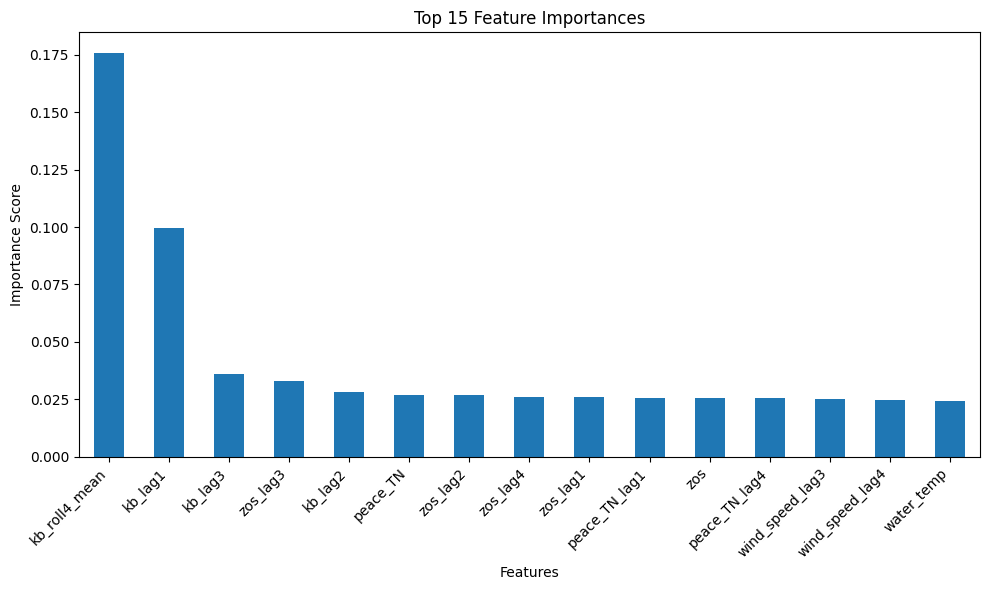

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Precision-Recall Curve Analysis

The Precision-Recall curve provides additional insight into model performance, particularly for imbalanced classification problems such as red tide prediction, where bloom events occur less frequently than non-bloom conditions. The curve demonstrates that the model maintains high precision across a wide range of recall values, indicating that when the model predicts a bloom, it is usually correct.

The model achieved an average precision (AP) score of 0.894, which reflects strong overall performance in identifying bloom events while minimizing false positives. As recall increases, precision gradually decreases, highlighting the expected tradeoff between capturing more true bloom events and introducing additional false alarms.

This analysis is particularly important for environmental applications, where management decisions may prioritize early detection of blooms even at the cost of increased false positives. The Precision-Recall curve shows that the model is capable of maintaining relatively high precision while still achieving strong recall, supporting its usefulness as a decision-support tool for monitoring and predicting red tide conditions.

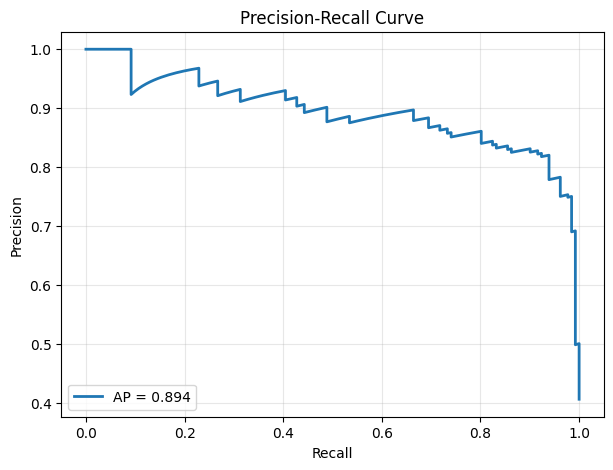

In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, linewidth=2, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### Predicted Probability Distribution and Threshold Interpretation

The predicted probability distribution provides insight into how confidently the model distinguishes between bloom and non-bloom conditions. The distribution shows a clear separation between the two classes, with most non-bloom observations concentrated at low predicted probabilities and bloom observations clustered at higher probability values. This separation indicates that the model is not only accurate, but also confident in its predictions.

The vertical line at the 0.5 threshold represents the default decision boundary used to classify observations. Most non-bloom cases fall well below this threshold, while the majority of bloom cases fall above it, supporting the effectiveness of the chosen cutoff. However, there is some overlap between the two distributions, which explains the presence of false positives and false negatives observed in the confusion matrix.

This visualization highlights the importance of threshold selection in practical applications. In the context of red tide prediction, the threshold could be adjusted depending on management priorities. Lowering the threshold would increase the detection of bloom events, improving recall but potentially increasing false positives. Conversely, raising the threshold would reduce false alarms but may result in missed bloom events. Overall, this plot demonstrates that the model produces well-separated probability estimates and provides flexibility for decision-making based on risk tolerance.

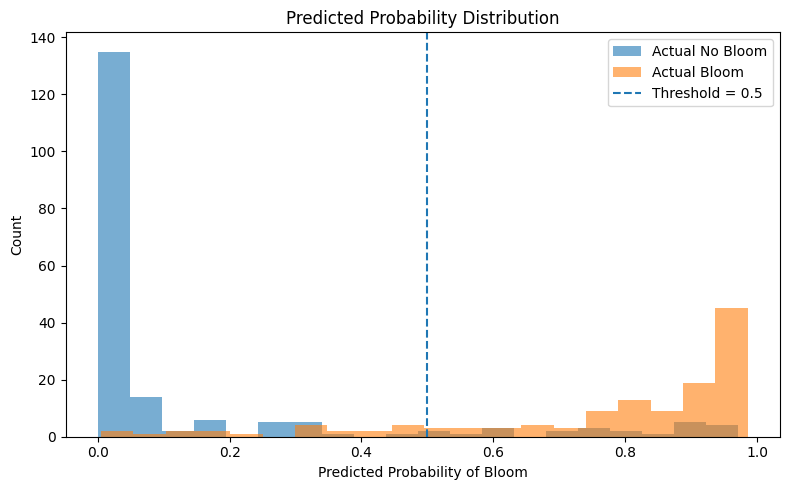

In [46]:
plt.figure(figsize=(8,5))
plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="Actual No Bloom")
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="Actual Bloom")
plt.axvline(0.5, linestyle="--", label="Threshold = 0.5")
plt.xlabel("Predicted Probability of Bloom")
plt.ylabel("Count")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### SHAP Analysis and Model Interpretation

The SHAP (SHapley Additive exPlanations) summary plot provides a detailed interpretation of how individual features influence the model’s predictions. Unlike traditional feature importance, which only ranks variables, SHAP values show both the magnitude and direction of each feature’s impact on the model output.

The results indicate that lagged bloom-related variables, particularly the rolling average of recent Karenia brevis concentrations and lagged bloom values, have the strongest influence on predictions. Higher values of these features are associated with increased likelihood of bloom classification, reinforcing the importance of temporal persistence in red tide dynamics. This suggests that bloom events are strongly influenced by prior conditions rather than occurring independently.

Environmental variables such as sea level anomalies, wind speed, and nutrient concentrations also contribute to the model, although their effects are more moderate and variable. The spread of SHAP values for these features indicates that their influence can differ depending on the specific environmental context, highlighting the complex and nonlinear nature of bloom formation.

Overall, the SHAP analysis confirms that the model captures both biological persistence and environmental variability as key drivers of red tide events. This provides strong interpretability and supports the validity of the model, demonstrating that its predictions are grounded in realistic environmental processes rather than purely statistical patterns.

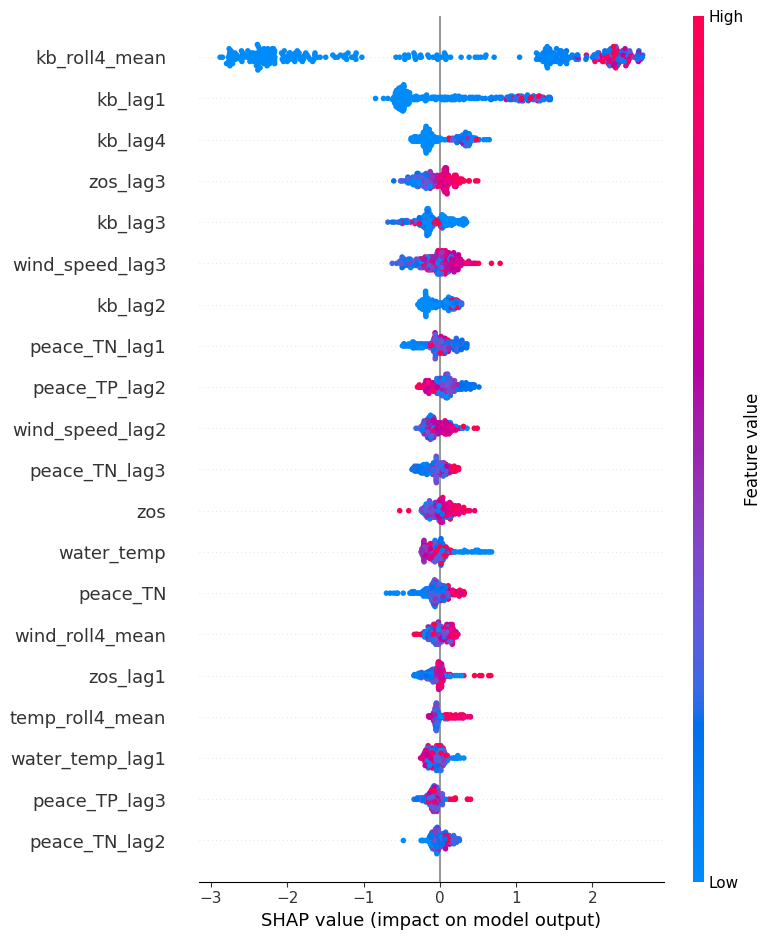

In [47]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### Interpretation of Model Refinement

The refined model produced meaningful improvements in predictive performance, particularly through the incorporation of lagged variables and threshold analysis. The model achieved strong overall performance, with an AUC of 0.94, indicating a high ability to distinguish between bloom and non-bloom conditions. Additional evaluation using the confusion matrix and precision-recall curve demonstrated that the model maintains balanced classification performance, with relatively low rates of false positives and false negatives.

The inclusion of lagged variables significantly enhanced model performance, suggesting that red tide dynamics are strongly influenced by prior environmental and biological conditions. Feature importance and SHAP analyses both indicated that recent Karenia brevis concentrations and lagged bloom values were the most influential predictors, reinforcing the importance of temporal persistence in bloom development.

Threshold analysis further demonstrated that model performance can be adjusted depending on management priorities. Lowering the classification threshold increased recall, allowing for improved detection of bloom events, while higher thresholds reduced false positives. This highlights the flexibility of the model as a decision-support tool, where tradeoffs between early detection and false alarms can be managed based on specific application needs.

Overall, the refined model successfully captures both temporal dependencies and environmental variability, providing a robust and interpretable framework for red tide prediction. These results are consistent with recent research demonstrating that machine learning models incorporating lagged environmental variables improve the ability to model and predict harmful algal bloom dynamics.

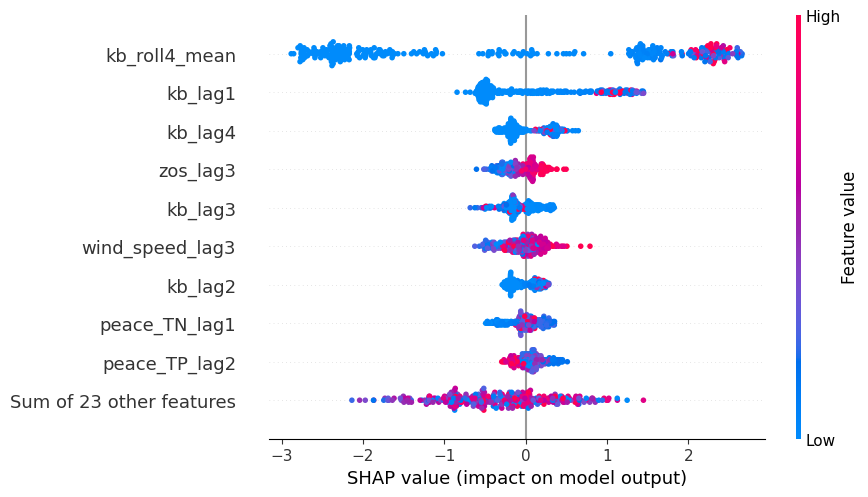

In [48]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

## Interpretation of model refinement

Model refinement produced meaningful but limited improvements in predictive performance. Lowering the classification threshold substantially increased recall, indicating that the baseline model contained bloom-related signal that was not captured under the default threshold.

The addition of lagged variables resulted in improved ROC-AUC and F1-score, suggesting that bloom occurrence is influenced by prior environmental conditions and that incorporating temporal structure enhances model performance.

Oversampling further increased recall to approximately 0.85, demonstrating that class imbalance was a major limitation of the baseline model. However, this improvement came at the cost of reduced precision and overall accuracy, reflecting an increase in false positive predictions.

Overall, these refinements improved the model’s ability to detect bloom events but did not substantially improve overall predictive accuracy. This suggests that while environmental variables contain useful information, harmful algal bloom dynamics are influenced by additional factors not captured in the dataset.

## Overall interpretation

The classification model demonstrates limited predictive ability, indicating that environmental variables alone are not sufficient to reliably predict harmful algal bloom occurrence in this dataset. While the model captures some structure in the data, its performance suggests that important drivers of bloom dynamics are either missing or not adequately represented.

SHAP analysis provides insight into how the model uses available variables, highlighting the importance of temperature and physical environmental conditions. However, these findings should not be interpreted as definitive ecological conclusions. Instead, they suggest potential relationships that warrant further investigation.

Overall, the results emphasize the complexity of harmful algal bloom systems, which are influenced by multiple interacting factors including nutrient availability, hydrodynamics, biological processes, and environmental variability. Future work should incorporate additional variables and more advanced modeling approaches to improve predictive performance.

ChatGPT (OpenAI, 2025) was used as a support tool for code structuring, debugging, and explanation of machine learning workflow. All data processing decisions, model design choices, interpretations, and final conclusions were independently reviewed and validated.